# Visualize V-JEPA Features using PCA
This notebook runs inference on a video using a V-JEPA model and visualizes the feature maps by reducing the 192-dimensional features to 3 dimensions (RGB) using PCA.


In [1]:
import os
import torch
import yaml
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import urllib.request
from decord import VideoReader, cpu

# We will use the V-JEPA model and utils from our app folder
from app.vjepa.utils import init_video_model


## 1. Define configurations and load the Model


In [2]:
config_path = "configs/pretrain/vitt16.yaml"
checkpoint_path = "logs/2026-06-24_20-17-05-jepa-latest.pth.tar"

with open(config_path, 'r') as y_file:
    params = yaml.load(y_file, Loader=yaml.FullLoader)

cfgs_model = params['model']
cfgs_data = params['data']
num_frames = cfgs_data.get('num_frames', 16)
tubelet_size = cfgs_data.get('tubelet_size', 2)
crop_size = cfgs_data.get('crop_size', 224)
patch_size = cfgs_data.get('patch_size', 16)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f"Initializing model on device: {device}")
encoder, _ = init_video_model(
    uniform_power=cfgs_model['uniform_power'],
    use_mask_tokens=cfgs_model['use_mask_tokens'],
    num_mask_tokens=len(params.get('mask', [])),
    zero_init_mask_tokens=cfgs_model['zero_init_mask_tokens'],
    device=device,
    patch_size=patch_size,
    num_frames=num_frames,
    tubelet_size=tubelet_size,
    model_name=cfgs_model['model_name'],
    crop_size=crop_size,
    pred_depth=cfgs_model['pred_depth'],
    pred_embed_dim=cfgs_model['pred_embed_dim'],
    use_sdpa=params['meta'].get('use_sdpa', False)
)

print(f"Loading checkpoint: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device)
encoder.load_state_dict(checkpoint.get('target_encoder', checkpoint.get('encoder')))
encoder.eval()
print("Model loaded successfully!")


Initializing model on device: cpu
INFO:root:MultiMaskWrapper(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed3D(
      (proj): Conv3d(3, 192, kernel_size=(2, 16, 16), stride=(2, 16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True, bias=True)
        (attn): Attention(
          (qkv): Linear(in_features=192, out_features=576, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=192, out_features=192, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): MLP(
          (fc1): Linear(in_features=192, out_features=768, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=768, out_features=192, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerN

## 2. Load and Preprocess Video
We will download a sample video and extract the first 16 frames.


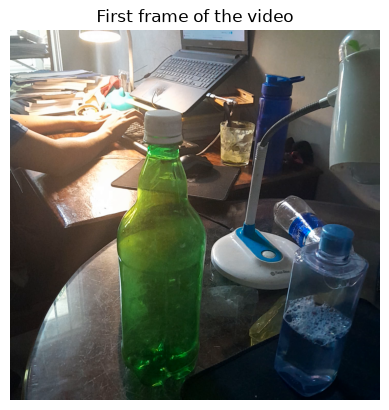

Video tensor shape: torch.Size([1, 3, 16, 224, 224])


In [3]:
# video_url = "https://raw.githubusercontent.com/pytorch/vision/main/test/assets/videos/R6llTwEh07w.mp4"
video_path = "../20260625_100642.mp4"

# if not os.path.exists(video_path):
#     print("Downloading sample video...")
#     urllib.request.urlretrieve(video_url, video_path)

vr = VideoReader(video_path, ctx=cpu(0))
frames = vr.get_batch(range(0, num_frames)).asnumpy() # Shape: (T, H, W, C)

# Display a frame
plt.imshow(frames[0])
plt.title("First frame of the video")
plt.axis('off')
plt.show()

# Preprocess for V-JEPA (Normalize and resize to 224x224)
import cv2
frames_resized = np.array([cv2.resize(f, (crop_size, crop_size)) for f in frames])

# PyTorch expects (B, C, T, H, W) and normalized to [0, 1] then ImageNet mean/std
video_tensor = torch.from_numpy(frames_resized).float() / 255.0
video_tensor = video_tensor.permute(3, 0, 1, 2) # (C, T, H, W)

# Normalize
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1, 1)
video_tensor = (video_tensor - mean) / std

video_tensor = video_tensor.unsqueeze(0).to(device) # (1, C, T, H, W)
print("Video tensor shape:", video_tensor.shape)


## 3. Run Inference and compute PCA


In [4]:
with torch.no_grad():
    try:
        features = encoder(video_tensor)
    except:
        features = encoder(video_tensor, masks=[])

print("Raw features shape:", features.shape)

# features shape: (1, 1568, 192)
# 1568 = (num_frames // tubelet_size) * (crop_size // patch_size) * (crop_size // patch_size)
# 1568 = (16 // 2) * (224 // 16) * (224 // 16) = 8 * 14 * 14

D = features.shape[-1]
features_np = features[0].cpu().numpy() # (1568, 192)

# Compute PCA to reduce from 192 to 3 dimensions (for RGB)
pca = PCA(n_components=3)
features_pca = pca.fit_transform(features_np) # (1568, 3)

# Normalize PCA components to [0, 1] for visualization
features_pca = (features_pca - features_pca.min()) / (features_pca.max() - features_pca.min())

# Reshape back to spatial dimensions (T_out, H_out, W_out, 3)
T_out = num_frames // tubelet_size
H_out = crop_size // patch_size
W_out = crop_size // patch_size

features_rgb = features_pca.reshape(T_out, H_out, W_out, 3)
print("PCA RGB Feature maps shape:", features_rgb.shape)


/home/bim/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Raw features shape: torch.Size([1, 1568, 192])
PCA RGB Feature maps shape: (8, 14, 14, 3)


## 4. Visualize Feature Maps Over Time


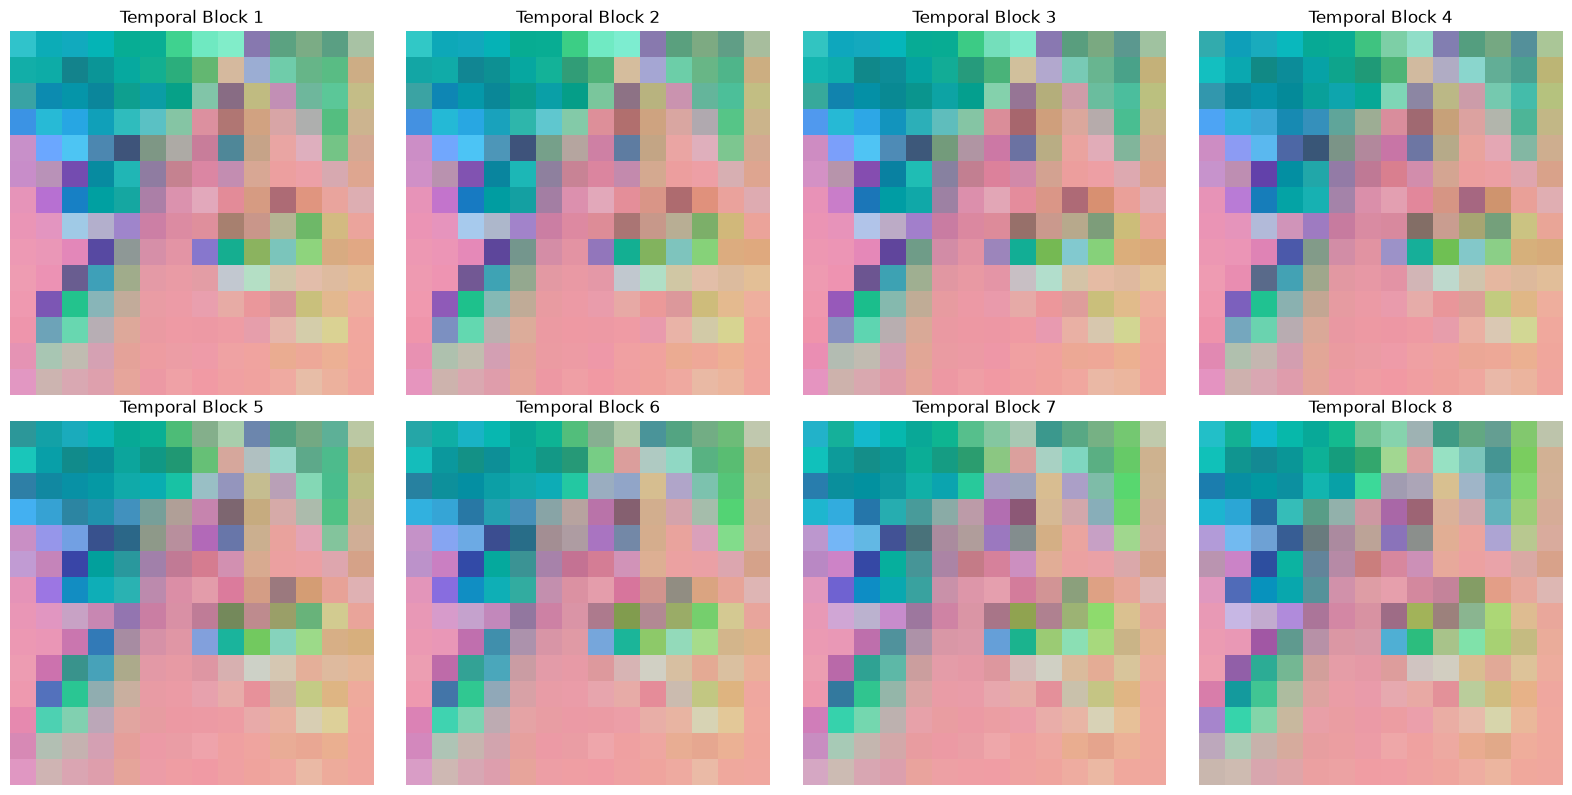

: 

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    if i < T_out:
        ax.imshow(features_rgb[i])
        ax.set_title(f"Temporal Block {i+1}")
        ax.axis('off')
plt.tight_layout()
plt.show()
